<a href="https://colab.research.google.com/github/davidsjohnson/wise24_xai_ac/blob/main/notebooks/tutorial_image_xai_task2_cnn_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explaining Facial Expression Recognition
# Notebook 1:  XAI for Affective Computing (SoSe2024)

In this notebook you will attempt to generate explanations for predictions of a facial expression recognition (FER) CNN trained on raw image data, using a subset of the [AffectNet dataset](http://mohammadmahoor.com/affectnet/). AffectNet is an image dataset of facial expressions in the wild, and is labeled with 8 facial expression categories: **Neutral, Happy, Sad, Surprise, Fear, Disgust, Anger, and Contempt**. (Have a look at the paper for more details https://arxiv.org/abs/1708.03985).

More information will be provided in the tutorial. This is meant to get you familar with the dataset and models being used.


To use this notebook, please make sure to go step by step through each of the cells review the code and comments along the way.

***NOTE**: This notebook runtime could be improved by using a GPU if available.*

## Notebook Setup

Make sure to uncomment code based on if you are running locally or via Google Colab

In [ ]:
## uncomment and run this cell to use Google Colab
!git clone https://github.com/davidsjohnson/wise24_xai_ac.git
# fix xgboost incompatiblity issue
%pip uninstall -y -q scikit-learn
%pip install -q scikit-learn==1.5.2

Cloning into 'wise24_xai_ac'...
remote: Enumerating objects: 502, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 502 (delta 21), reused 14 (delta 5), pack-reused 460 (from 1)
Receiving objects: 100% (502/502), 103.95 MiB | 12.08 MiB/s, done.
Resolving deltas: 100% (81/81), done.
Updating files: 100% (398/398), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 61.7 MB/s eta 0:00:00


In [ ]:
import sys
import os
# sys.path.append(os.path.realpath('../'))  # uncomment this line if you are running this notebook locally
sys.path.append(os.path.realpath('wise24_xai_ac')) # uncomment this line if you are running this notebook on Google Colab

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import randint, uniform

import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import torch.nn as nn

import seaborn as sns
import matplotlib.pyplot as plt

from skimage import io

import utils
import img_utils
import models
import evaluate

In [ ]:
colab = True # change to False if running locally
base_dir = Path('../data/') if not colab else Path('wise24_xai_ac/data/')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## XAI for FER with  Convoluational Neural Nets

### Setup the Pytorch Data Loader

In [ ]:
#class labels
class_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

# Setup XAI Data from AffectNet Deep Learning Model
TRAIN_MEAN = [0.485, 0.456, 0.406]
TRAIN_STD = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
    transforms.Resize((224, 224))
])

data_dir = base_dir / 'affectnet/val_class'
dataset = datasets.ImageFolder(root=data_dir, transform=test_transform)
images_og = [io.imread(f[0]) for f in dataset.imgs]
y_true = np.array([f[1] for f in dataset.imgs])
y_labels = [class_names[f[1]] for f in dataset.imgs]
dataloader = DataLoader(dataset, batch_size=80, shuffle=False)

### Load Pretrained Model

In [ ]:
# download checkpoint
ckpt_link = 'https://uni-bielefeld.sciebo.de/s/0tAa2wPhGxSDjbM/download'
ckpt_path = utils.download_file(ckpt_link,
                                'affectnet.pth',
                                cache_dir= base_dir / 'affectnet/model',
                                extract=False,
                                force_download=False
                                )
ckpt_path

File already exists at: wise24_xai_ac/data/affectnet/model/affectnet.pth


PosixPath('wise24_xai_ac/data/affectnet/model/affectnet.pth')

In [ ]:
model = models.ResNet18(n_classes=len(class_names), pretrained=True)
model.to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval();

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]
<ipython-input-7-c89b7f1c43de>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be

### Evaluation of Model

This model performs much better than the AU dataset, but still with only around $60\%$ accuracy.  But this is pretty close the state-of-the-art for the AffectNet dataset

In [ ]:
inverse_weights = torch.from_numpy(1.0/np.array([74874, 134415, 25459, 14090, 6378, 3803, 24882, 3750])).type(torch.float32).to(device)
loss = torch.nn.CrossEntropyLoss(weight=inverse_weights)
_, _, y_preds, probs = evaluate.evaluate_model(model, dataloader, loss, device=device)

y_preds = np.array(y_preds)
# validate predictions and true values
(y_preds == y_true).mean()

Evaluation Loss: 1.3183, Evaluation Accuracy: 0.5875


0.5875

## Generate Explanations

In [ ]:
!pip install -q shap
!pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.9 MB/s eta 0:00:00


In [ ]:
import shap

### Task 1 - Generate Local Explanations

In this task you will generate local explanations with Shap and [Captum](https://captum.ai/).

 You can review the [Image Examples in the SHAP documenetation](https://shap.readthedocs.io/en/latest/image_examples.html) for help in this task.

 As well as the [Captum tutorials](https://captum.ai/tutorials/).


**Task 1.1:** Select 6 image that you want to gain explanations for. Choose 3 correct and 3 incorrect explanations

**Task 1.2:** Generate Local Explanations for each image using the default SHAP image explainer, see the ["Explain ResNet50 ImageNet using Partition Explainer"](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Image%20Multi%20Class.html) example.  Similar to the example, plot the saliency maps in the order of their prediction probabilities (but for all classes not just the first 4)

Altough, the example is for Tensorflow, the main idea stays the same.  You will need a `masker` and a `model` wrapper that takes an array of raw images, applies the image transform and returns the probabilities for each image.

Note: since AffectNet images are all different resolutions, I've included code to resize all the images before sending to SHAP. Thie makes it easier to deal with all images at once (rather than looping)

**Task 1.2:** Generate local explanations using the backpropagation based IntegratedGradients method from Captum.  

See the [TorchVision example](https://captum.ai/tutorials/CIFAR_TorchVision_Interpret) for help.  

You should generate explanations at least for the model prediction. You can also generate explanations for the true class to try to identify why it wasn't predicted.  

**Task 1.4:** Answer the Questions at the end.

**Preview the Dataset with Predictions**

The code below will display images from the XAI dataset.
- Try changing value of `start` to get a new set of images (there are 10 images for each class; for example, the class happy will be at indexes 10-19)
- Search through the images to find some that might be interesting to Explain

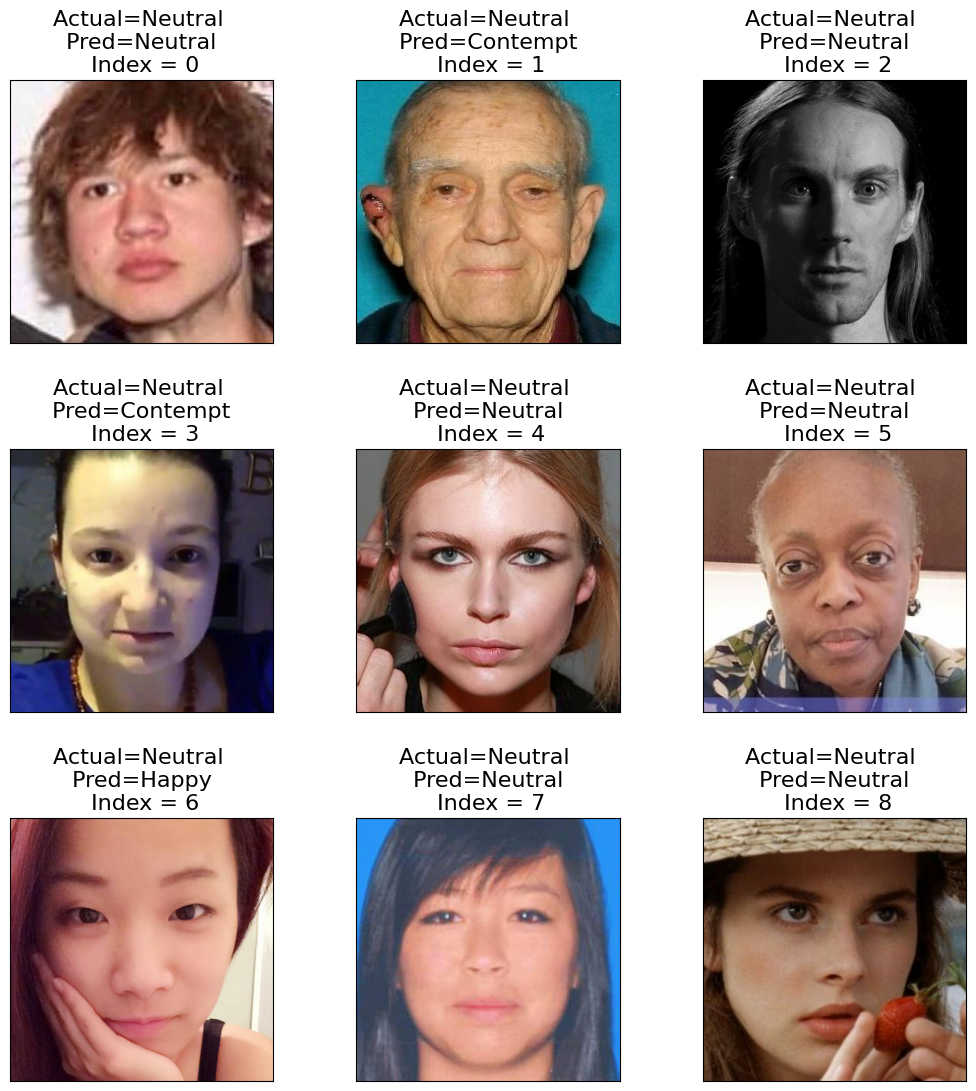

In [ ]:
start=0
img_utils.display_nine_images(images_og, y_true, y_preds, start)

In [ ]:
###### Enter your Code Here ######
##################################

img_idxs_corr = []
img_idxs_incorr = []

In [ ]:
img_idxs_corr = [21, 40, 59]
img_idxs_incorr = [29, 48, 58]

all_idxs = img_idxs_corr + img_idxs_incorr

#### Partition Explainer

In [ ]:
# model wrapper to enable image transform
def f(X):
  x_pre = []
  for x in X:
    x = test_transform(x)
    x_pre.append(x)
  x = torch.stack(x_pre).to(device)
  return model(x)

In [ ]:
# resize images so they all can be explained together
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.ToPILImage()
])
images_resized = np.array([transform(x) for x in images])

In [ ]:
masker =  shap.maskers.Image("inpaint_telea", images_resized[0].shape)
explainer = shap.Explainer(f,masker, output_names=class_names)

x_xai = images_resized[all_idxs]
y_xai = y_true[all_idxs]
y_xai_labels = [class_names[i] for i in y_xai]

exps = explainer(x_xai, max_evals=500, batch_size=1, outputs=shap.Explanation.argsort.flip)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  17%|█▋        | 1/6 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 3/6 [00:38<00:25,  8.60s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  83%|████████▎ | 5/6 [01:16<00:15, 15.21s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 6/6 [01:35<00:00, 16.30s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 7it [01:54, 19.02s/it]


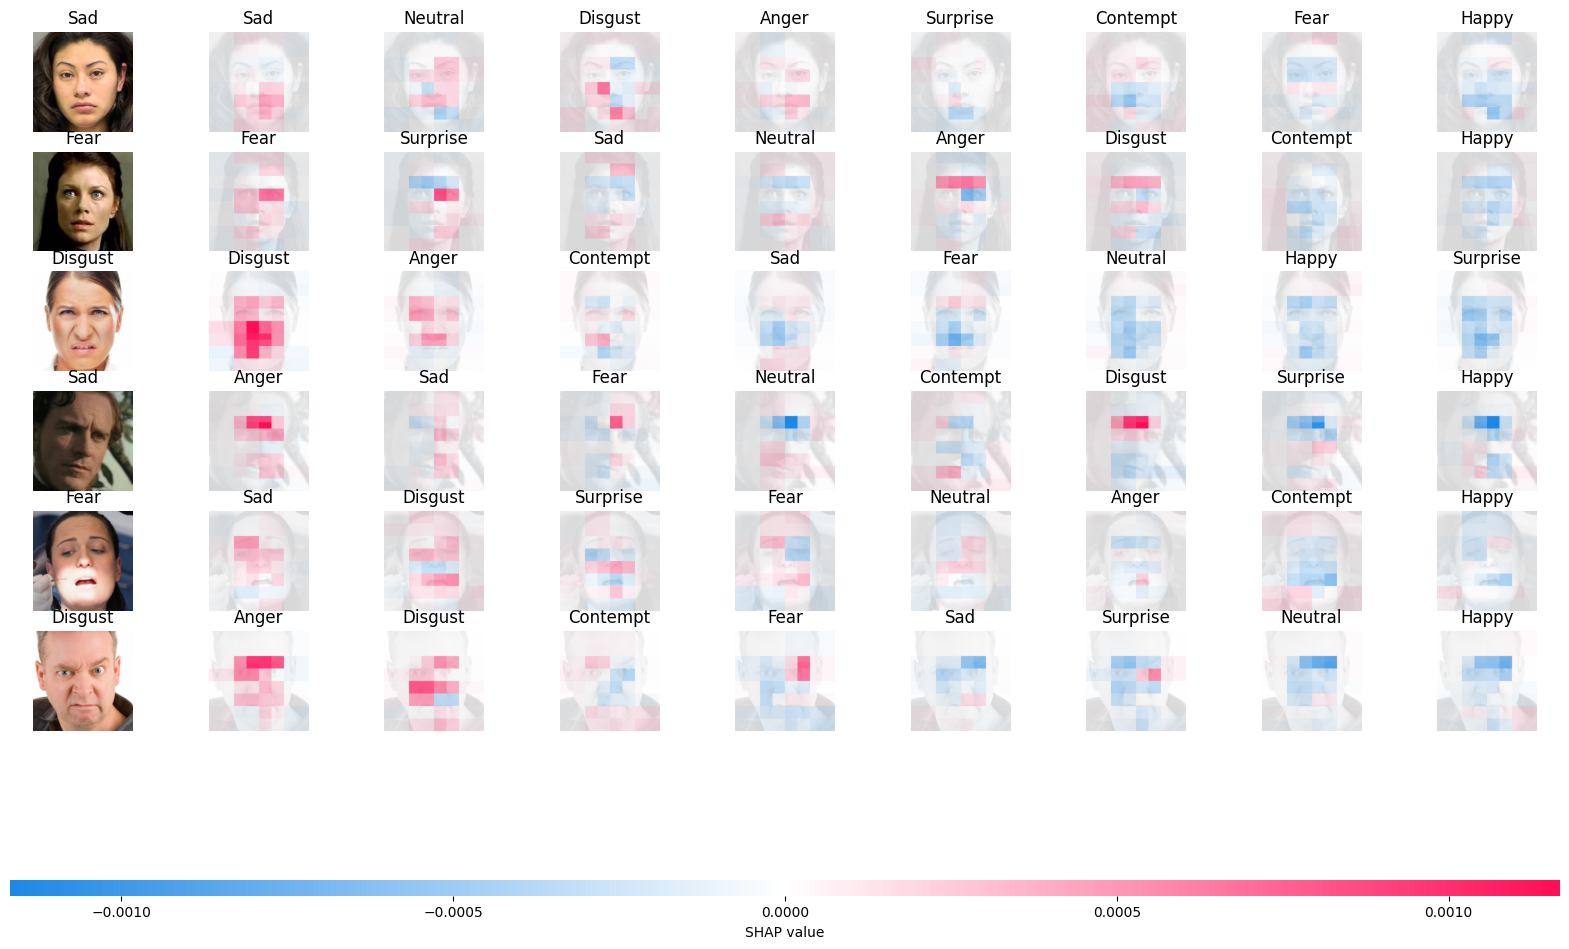

In [ ]:
shap.image_plot(exps, true_labels=y_xai_labels)

#### Captum - Backpropagation


In [ ]:
from captum.attr import IntegratedGradients, DeepLift, GuidedGradCam
from captum.attr import visualization as viz

In [ ]:
# Batch size is 80 so all data should be in batch
batch = next(iter(dataloader))
images, labels = batch
images, labels = images.to(device), labels.to(device)

x_xai = images[all_idxs]
y_xai = y_true[all_idxs]
y_pred_xai = y_preds[all_idxs]
y_xai_labels = [class_names[i] for i in y_xai]

# baseline = torch.zeros(x_xai[0:1].shape).to(device)
# baseline = images.mean(axis=(0,), keepdims=True).to(device)
baseline = images[:11].mean(axis=(0,), keepdims=True).to(device)


explainer = IntegratedGradients(model)

In [ ]:
baseline.shape, x_xai.shape

(torch.Size([1, 3, 224, 224]), torch.Size([6, 3, 224, 224]))

In [ ]:
model = models.ResNet18(n_classes=len(class_names), pretrained=True)
model.to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval();

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
<ipython-input-124-c89b7f1c43de>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` f

In [ ]:
model.zero_grad()
attrs_pred = explainer.attribute(x_xai, target=y_pred_xai.tolist(), baselines=baseline)
attrs_true = explainer.attribute(x_xai, target=y_xai.tolist(), baselines=baseline)

In [ ]:
attrs_pred = np.transpose(attrs_pred.cpu().detach().numpy(), (0, 2, 3, 1))
attrs_true = np.transpose(attrs_true.cpu().detach().numpy(), (0, 2, 3, 1))
attrs_pred.shape, attrs_true.shape

((6, 224, 224, 3), (6, 224, 224, 3))

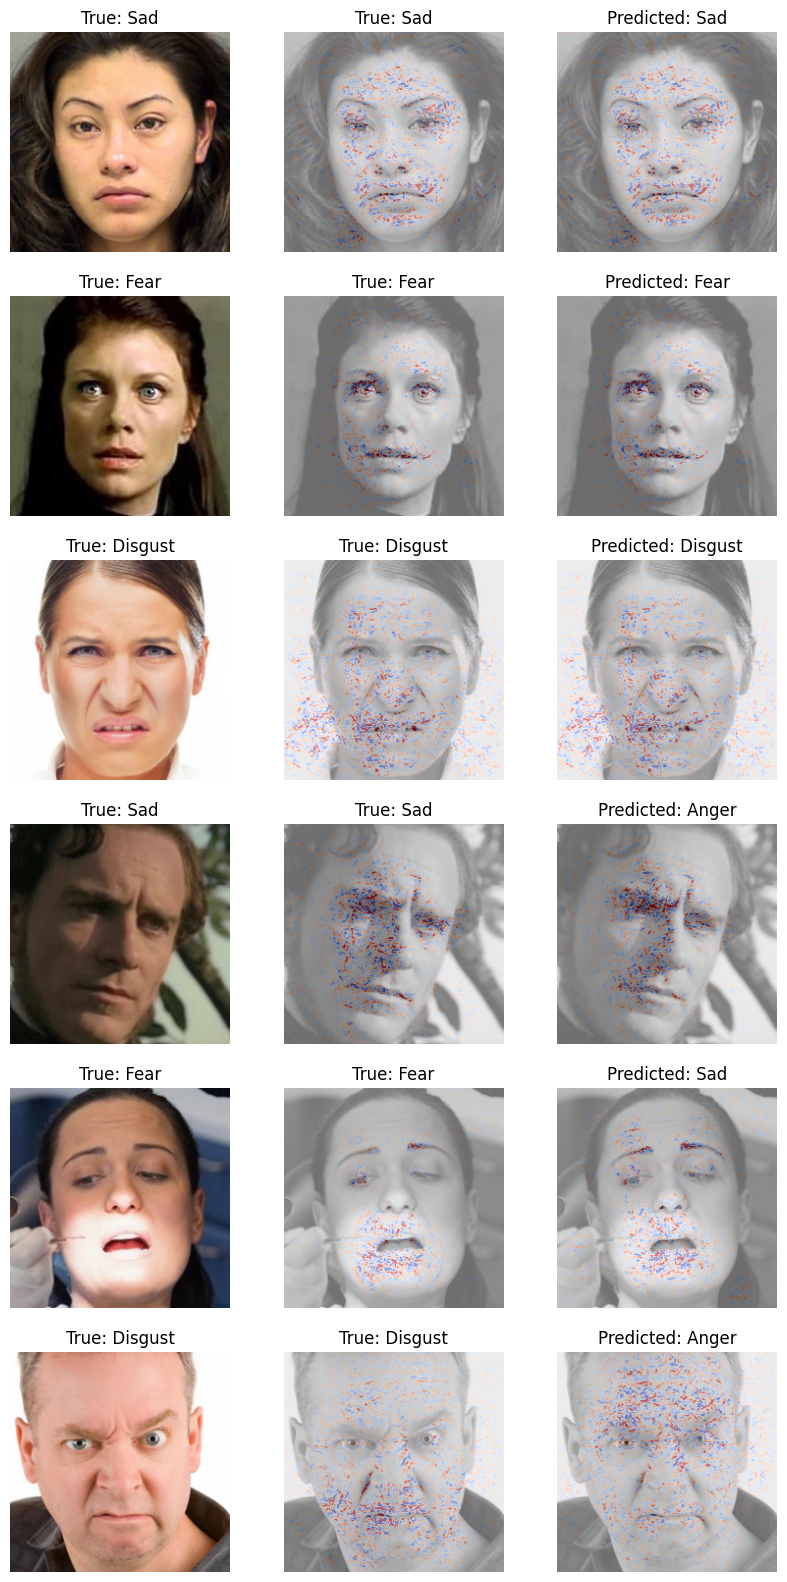

In [ ]:
fig, axes = plt.subplots(6, 3, figsize=(10, 20))

for i in range(6):
    axes[i, 0].imshow(images_resized[all_idxs[i]])
    axes[i, 0].set_title(f'True: {y_xai_labels[i]}')
    axes[i, 0].axis('off')

    viz.visualize_image_attr(
        attrs_true[i],
        images_resized[all_idxs[i]],
        method="blended_heat_map",
        show_colorbar=False,
        sign="all",
        outlier_perc=10,
        cmap='coolwarm',
        plt_fig_axis=(fig, axes[i, 1]),
        use_pyplot=False,
        fig_size = (3,3)
    )
    axes[i, 1].set_title(f'True: {y_xai_labels[i]}')
    axes[i, 1].axis('off')

    viz.visualize_image_attr(
        attrs_pred[i],
        images_resized[all_idxs[i]],
        method="blended_heat_map",
        show_colorbar=False,
        sign="all",
        outlier_perc=10,
        cmap='coolwarm',
        plt_fig_axis=(fig, axes[i, 2]),
        use_pyplot=False,
        fig_size = (3,3)
    )
    axes[i, 2].set_title(f'Predicted: {class_names[y_preds[all_idxs[i]]]}')
    axes[i, 2].axis('off')

# fig.tight_layout()
# plt.show()

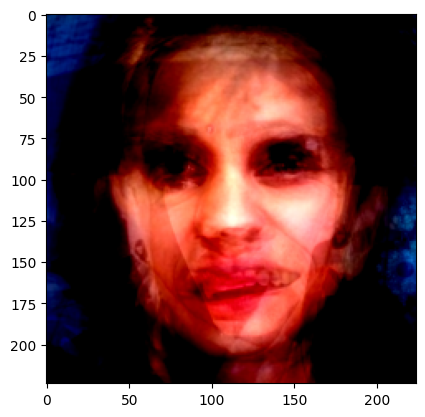

In [ ]:
plt.imshow(baseline[0].detach().cpu().numpy().transpose(1, 2, 0))

### Questions

1. In the tabular data notebook we explored Global explanations, but did not do so in this notebook. What is the challenge with applying global explanations to images? How could we implement global explanations for images?

2. Why does the `Partition` explainer need a `masker`? How does this approach differ from a backpropagation approach like the DeepExplainer?

3. What insights have you learned from reviewing the generated saliency maps?  Do they explain how the model made the given prediction? And would do they help validate that the prediction is correct?  

4. What uses do you think saliency maps are good for?